## 0.  MOTIVATION

We independently replicate the findings of the paper `"A data-driven approach to predict the success of bank telemarketing"` by S.Moro, P.Cortez,P.Rita (2014), DOI:10.1016/j.dss.2014.03.001. The authors predict the success of telemarketing calls for selling bank long-term
deposits for a Portuguese bank, with data collected from 2008 to 2013, ordered by date. The initial dataset contained 150 features related to bank client, product and social-economic attributes, but the authors managed to isolate 21 features (+ the target, i.e. if a client subscribed a long-term deposit) which are sufficient for accurately predicting the success rate. This reduced dataset is the one used in this notebook. More precisely, we take the dataset from `https://archive.ics.uci.edu/dataset/222/bank+marketing`, specifically dataset 1), i.e. `bank-additional-full.csv`. This is not *exactly* the dataset used in the paper, but it is very close.

The dataset is indeed enriched by the addition of five new social and economic features/attributes which we specify, and whose inclusion greatly improves the prediction of whether a client subscribes a long-term loan.

IMPORTANT: As noticed in the documentation in `bank-additional-names.txt`, we drop the feature "duration" which measures the last contact duration, in seconds, of  call with the potential client since it brings leakage. We also rename the final column as "deposit" instead of "y".

We compare the results obtained with and without the additional social features, als comparing it to the results presented in the article.

## 1. Import necessary packages


In [11]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, confusion_matrix, f1_score)

## 2. Load the dataset and define features and objective sets.


In [12]:

df = pd.read_csv("bank-additional-full.csv", delimiter=";")
df.drop(columns="duration", inplace=True) #As noted in the bank-additional-names.txt file accompanying the dataset the duration is not known a priori and it       should not be used in training predictive models
df.rename(columns={'y': "deposit"}, inplace=True)

ECONOMIC = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
NUMERICAL = ["age", "campaign", "pdays", "previous"] + ECONOMIC
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "day_of_week", "poutcome"]

FEATURES = NUMERICAL + CATEGORICAL
FEATURES_reduced = [c for c in FEATURES if c not in ECONOMIC]
TARGET = "deposit"

## 3. EDA

In this case the dataset refers to a published paper, so it would be safe to assume that it is clean. However, it is a good practice never to skip this step.

Note: Duplicate rows are admissible since, as noted in the introduction, the data is ordered by date even though a "date" feature is missing.

We refer to `bank-additional-names.txt` for the details on the dataset. The raw dataset has 41188 rows and 21 features, with the last one (renamed "deposit") being the target feature, which determines if a person subscribes a bank deposit or not. We dropped the feature "duration" so the features are 20.

So, the final dataframe has 41188 rows and 20 columns: 19 features and 1 target.

We now describe each feature to better understand the setting. Features refer to both

- "age" : (Numerical).
- "job" : (Categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown").
- "marital" : (Categorical: "divorced","married","single","unknown").
- "education" : (Categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown").
- "default" : Has default credit? (Binary: "yes", "no", "unknown").
- "housing" : Has housing loan? (Categorical: "no","yes","unknown").
- "loan" : Has personal loan? (Categorical: "no","yes","unknown").
- "contact" : Contact communication type (Categorical: "cellular","telephone").
- "month": (Categorical: "jan", "feb", "mar", ..., "nov", "dec").
- "day_of_week" : (Categorical: "mon","tue","wed","thu","fri").
- "campaign" : Number of contacts performed during this campaign and for this client (Numerical).
- "pdays": Number of days that passed by after the client was last contacted from a previous campaign (Numerical; 999 means client was not previously contacted).
- "previous": Number of contacts performed before this campaign and for this client (Numerical).
- "poutcome": Outcome of the previous marketing campaign (Categorical: "failure","nonexistent","success").
### social and economic context attributes
- emp.var.rate: Employment variation rate - quarterly indicator (Numerical).
- cons.price.idx: Consumer price index - monthly indicator (Numerical).
- cons.conf.idx: Consumer confidence index - monthly indicator (Numerical).
- euribor3m: Euribor 3 month rate - daily indicator (Numerical).
- nr.employed: Number of employees - quarterly indicator (Numerical).
### target
- y: Has the client subscribed a term deposit? (Binary: "yes","no").

In [13]:
# Check the dimensions of the dataframe

if df.shape[0] != 41188 or df.shape[1] != 20:
	warnings.warn("WARNING! Dataframe dimensions inconsistent with the documentation!")
else:
	print(f"The DataFrame has 41188 rows and 20 columns, as claimed in the .txt documentation file.")

The DataFrame has 41188 rows and 20 columns, as claimed in the .txt documentation file.


In [14]:
# Check for heterogeneous entries and missing values

if "object" in df.dtypes.tolist():
    warnings.warn("WARNING! : Object type is inconsistent, check inconsistent values in bject columns.")
else:
    print(f"\n\nNo object column found, i.e. data type is consistent in each column.\n")

s = df.isna().sum().sum()

if s >0:
	warnings.warn(f"WARNING! : There are {s} NaN values in the dataframe.")
else:
	print(f"There are no missing values.")




No object column found, i.e. data type is consistent in each column.

There are no missing values.


### 3.1 We now check each feature separately.

In [15]:
#We check the values of categorical data vs the ones reported in the documentation .txt file.
POSSIBLE_JOBS = {"admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired", "self-employed",
                 "services", "student", "technician", "unemployed", "unknown"}
if set(df["job"].tolist()) != POSSIBLE_JOBS:
	warnings.warn("WARNING! : Job type is inconsistent")

POSSIBLE_MARITAL_STATUS = {"divorced", "married", "single", "unknown"}
if set(df["marital"].tolist()) != POSSIBLE_MARITAL_STATUS:
	warnings.warn("WARNING! : Job type is inconsistent")

EDUCATION = {"basic.4y", "basic.6y", "basic.9y", "high.school", "illiterate", "professional.course",
             "university.degree", "unknown"}
if set(df["education"].tolist()) != EDUCATION:
	warnings.warn("WARNING! : Job type is inconsistent")

POSSIBLE_DEFAULT = {"yes", "no", "unknown"}
if set(df["default"].tolist()) != POSSIBLE_DEFAULT:
	warnings.warn("WARNING! : Default type is inconsistent")

POSSIBLE_HOUSING = {"yes", "no", "unknown"}
if set(df["housing"].tolist()) != POSSIBLE_HOUSING:
	warnings.warn("WARNING! : Housing type is inconsistent")

POSSIBLE_LOAN = {"yes", "no", "unknown"}
if set(df["loan"].tolist()) != POSSIBLE_LOAN:
	warnings.warn("WARNING! : Loan type is inconsistent")

POSSIBLE_CONTACT = {"cellular", "telephone"}
if set(df["contact"].tolist()) != POSSIBLE_CONTACT:
	warnings.warn("WARNING! : Contact type is inconsistent")

POSSIBLE_MONTH = {"jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"}
if not set(df["month"].tolist()).issubset(POSSIBLE_MONTH):
	warnings.warn("WARNING! : Month type is inconsistent")

POSSIBLE_DAY_OF_WEEK = {"mon", "tue", "wed", "thu", "fri"}
if set(df["day_of_week"].tolist()) != POSSIBLE_DAY_OF_WEEK:
	warnings.warn("WARNING! : Day_of_week type is inconsistent")

POSSIBLE_POUTCOME = {"failure", "nonexistent", "success"}
if set(df["poutcome"].tolist()) != POSSIBLE_POUTCOME:
	warnings.warn("WARNING! : Poutcome type is inconsistent")

#We check that the numerical features related to contacts are non-negative, with pdays additionally admitting the sentinel value 999.
if ((df["age"]<0) | (df["age"]>=130)).sum() >0:
	warnings.warn("WARNING! Age values are inconsistent")

if (df["campaign"]<0).sum() >0:
	warnings.warn("WARNING! Campaign values are inconsistent")

if ((df["pdays"]<0) | (df["pdays"]>999)).sum() >0:
	warnings.warn("WARNING! Pdays values are inconsistent")

if (df["previous"]<0).sum() >0:
	warnings.warn("WARNING! Previous values are inconsistent")

print("All categorical and contact-related numerical features are consistent with the documentation.")


All categorical and contact-related numerical features are consistent with the documentation.


In [16]:
#Finally, we check the five social and economic context attributes and the target.

#These are quarterly/monthly/daily indicators, so we only check that they are finite numbers, without imposing hard bounds (unlike the other numerical features, there is no documented valid range for them).
ECONOMIC_FEATURES = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
if not np.isfinite(df[ECONOMIC_FEATURES]).all().all():
	warnings.warn("WARNING! : There are non-finite values among the economic/social features")

#euribor3m and nr.employed are, respectively, an interest rate and a headcount, so they must be strictly positive.
if (df["euribor3m"]<=0).sum() >0:
	warnings.warn("WARNING! Euribor3m values are inconsistent")

if (df["nr.employed"]<=0).sum() >0:
	warnings.warn("WARNING! Nr.employed values are inconsistent")

#Lastly, we check the target: the client either subscribed a deposit or did not.
POSSIBLE_DEPOSIT = {"yes", "no"}
if set(df[TARGET].tolist()) != POSSIBLE_DEPOSIT:
	warnings.warn("WARNING! : Deposit (target) type is inconsistent")
else:
	print("\nAll economic/social features are finite and consistent, and the target is binary as expected.")


All economic/social features are finite and consistent, and the target is binary as expected.


Now that we are sure the data is clean, we can start with the real EDA. We focus first on numerical features, and later on categorical ones.


### EDA on numerical features

 In numerical features, `pdays = 999` denotes clients which have never been previously contacted. This flag value shifts the distribution of `pdays`, so we add one column and modify `pdays`:
  . `was_contcted`: Binary, equal to `True` if the client was previously contacted, `False` otherwise.
  . `pdays`: The value of `pdays` if this is ` != 999`, otherwise we set it to `NaN`.

In [17]:
NO_PREV = 999 #flag value for nt having been previously contacted
df["was_contacted"] = (df["pdays"] != 999)
df.loc[df["pdays"]==NO_PREV, "pdays"] = np.nan

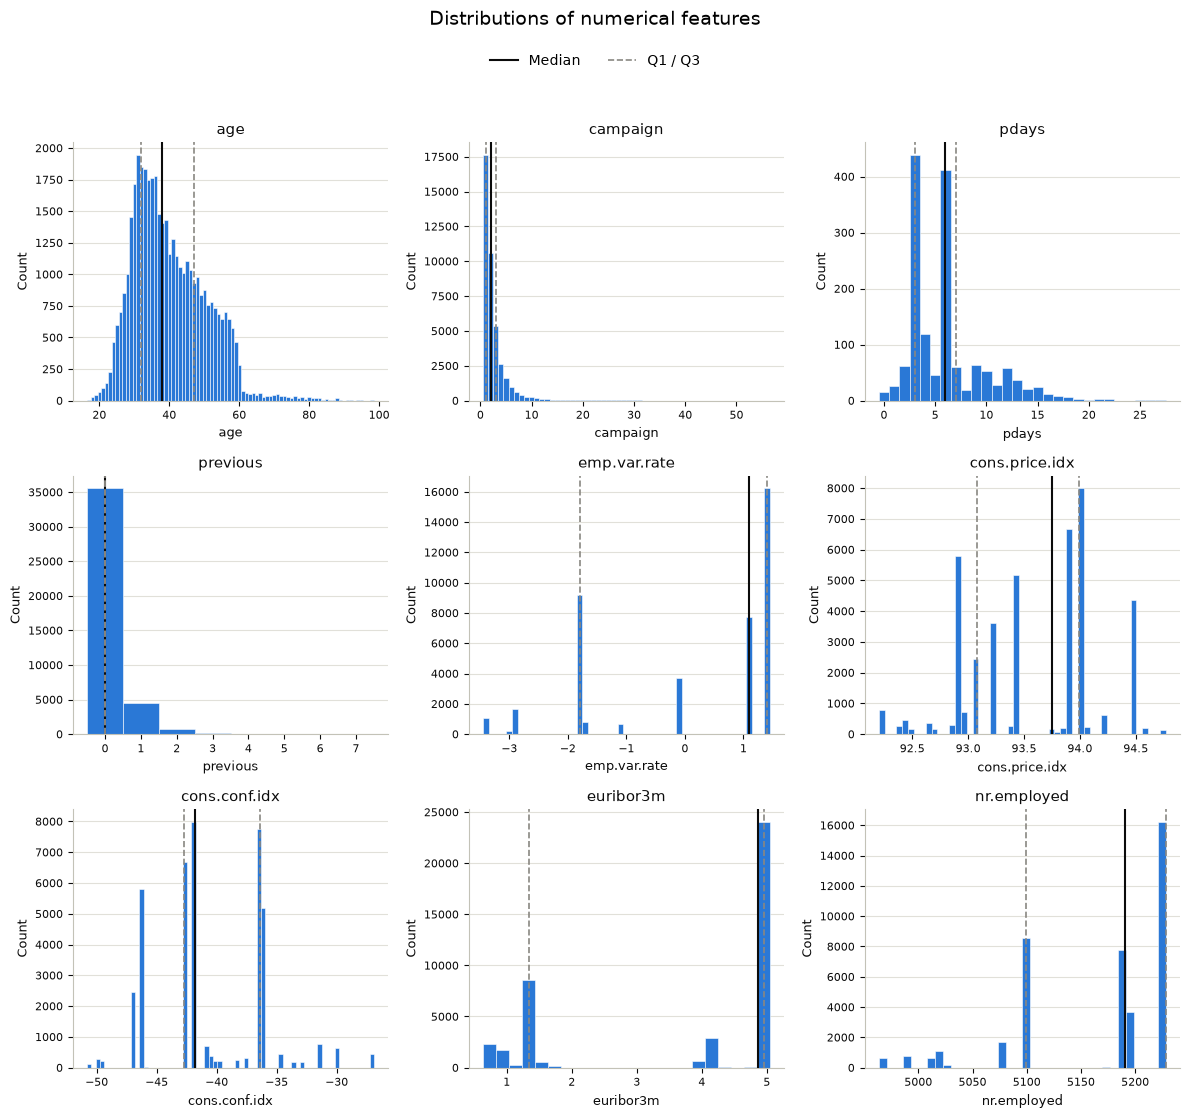

In [18]:
BAR_COLOR = "#2a78d6"       # single sequential hue for the bars
MEDIAN_COLOR = "#0b0b0b"    # primary ink
QUANTILE_COLOR = "#898781"  # muted ink
GRID_COLOR = "#e1e0d9"      # hairline gridline
AXIS_COLOR = "#c3c2b7"      # baseline/axis


def value_aligned_bins(values, max_bins=100, max_unique=250, rtol=1e-6):
    #Returns bin edges of constant width, each bin centred on one distinct value, when the distinct
    #values lie on a regular lattice (all gaps integer multiples of the smallest). The bin width is
    #that smallest gap; gaps in the lattice become empty bins.
    #Returns "auto" when the values are not on a lattice, when there are more than `max_unique`
    #distinct values, or when the lattice would need more than `max_bins` bins.
    uniques = np.unique(np.asarray(values, dtype=float))
    uniques = uniques[np.isfinite(uniques)]

    if uniques.size == 0:
        return "auto"
    if uniques.size == 1:
        return np.array([uniques[0] - 0.5, uniques[0] + 0.5])
    if uniques.size > max_unique:
        return "auto"

    gaps = np.diff(uniques)
    step = gaps.min()
    if step <= 0:
        return "auto"

    multiples = gaps / step
    if not np.allclose(multiples, np.round(multiples), rtol=rtol, atol=1e-9):
        return "auto"

    n_bins = int(round((uniques[-1] - uniques[0]) / step)) + 1
    if n_bins > max_bins:
        return "auto"

    return uniques[0] - step / 2 + step * np.arange(n_bins + 1)


n_rows = n_cols = int(np.ceil(np.sqrt(len(NUMERICAL))))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, NUMERICAL):
    data = df[col].dropna()
    bins = value_aligned_bins(data.values)
    ax.hist(data, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.4, zorder=2)

    q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
    ax.axvline(median, color=MEDIAN_COLOR, linestyle="-", linewidth=1.5, zorder=3, label="Median")
    ax.axvline(q1, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3, label="Q1 / Q3")
    ax.axvline(q3, color=QUANTILE_COLOR, linestyle="--", linewidth=1.2, zorder=3)

    ax.set_title(col, fontsize=11, color="#0b0b0b")
    ax.set_xlabel(col, fontsize=9, color="#0b0b0b")
    ax.set_ylabel("Count", fontsize=9, color="#0b0b0b")
    ax.tick_params(labelsize=8, colors="#0b0b0b")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS_COLOR)

#Remove any unused axes (if the grid has more cells than features).
for ax in axes[len(NUMERICAL):]:
    fig.delaxes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.03), fontsize=10)
fig.suptitle("Distributions of numerical features", fontsize=14, y=1.06)
fig.tight_layout()
plt.show()

We learn a few things from a simple visual inspection of the data:
- The campaign mostly targets people between 30 and 40, with a sharp drop after 60.
- Most people are contacted either once or twice at most.
- When people are contacted again after a previous campaign, this usually happens before a week.
- Most people in this campaign were never contacted by previous ones.

The economic and social features (i.e. the last five ones) are scattered and do not give any immediate insight.


### EDA on categoical features
